In [ ]:
from pathlib import Path
import pandas as pd

from src import DualModel, DualModelOptions, LTownSpecifics, calculate_correction_flows

Monkey patch to oopnet.reader.reading_modules.read_system_operation.read_demands applied.


# Data sources

In [ ]:
inp = Path(r"data\networks\L-TOWN.inp")

In [ ]:
# Dummy data
heads = pd.read_parquet(r"data\dummy_data\data_03_primal_head.parquet")
inflows = pd.read_parquet(r"data\dummy_data\data_05_primal_flow.parquet")
pump_flows = pd.read_parquet(r"data\dummy_data\data_06_primal_pump_flow.parquet")

# Reindex so start day == Monday (matches patterns)
sd = pd.Timestamp("2018-12-31")
heads.index += sd
inflows.index += sd
pump_flows.index += sd

In [ ]:
# Get arbitrary leak-free slice to create correction flow
indexer = pd.IndexSlice["2019-01-01 12:00:00":"2019-01-18 12:00:00"]

head_data = heads[LTownSpecifics.pressure_sensors].loc[indexer]
inflow_data = inflows[LTownSpecifics.inflow_pipes].loc[indexer]
pump_data = pump_flows[LTownSpecifics.pumps].loc[indexer]

# Dual Model

In [ ]:
# Configs (these are True by default)

# for fixed boundary conditions
DualModelOptions.use_inflow_replacement = True

# for flow correction
DualModelOptions.use_virtual_flow_correction_patterns = True

# adjust base demand patterns (and correction patterns) for arbitrary start dates and times, this is very important
DualModelOptions.cyclic_pattern_wrapping = True

In [ ]:
# build dual model
dm = DualModel(
    base_inp=inp,
    pressure_sensor_node_ids=LTownSpecifics.pressure_sensors,
    pump_ids=LTownSpecifics.pumps,
    inflow_mapping=LTownSpecifics.inflow_mapping,
)

dm.nw.save(r"data\output\temp\dm_fresh.inp")

Demand read with modified demand reader.


## Run simulation

In [ ]:
# run simulation of ata slices, uses tempfile library to write model
# oopnet network wrapper -> tempfile -> epyt simulator -> virtual flow dataframe
r = dm.run_simulation(
    heads=head_data,
    inflows=inflow_data,
    pump_flows=pump_data,
    aggregate=False, # if False, returns VF for each VR
)

Applied setTimeSimulationDuration((1468800.0,)) option.
Loaded epyt instance of: dual_model.inp


c:\Users\jkoslo\.conda\envs\iole\Lib\site-packages\epyt\epanet.py:14337: UserWarning: WARNING: Valves cannot deliver enough flow.
  warnings.warn(errmssg.value.decode())


run_simulation executed in 4.27 seconds


# Add correction

In [ ]:
# utility function that aggregates over datetime components (dayofweek, hour, minute)
corr_flows = calculate_correction_flows(
    df=r,
    start_dow=DualModelOptions.correction_pattern_start_day,
    adjust_index=True,
    period="week", # only possibility atm
    )

# add correction flows to main instance, these are persistent and do not need to be readded for each simulation call unlike other data
dm.set_correction_flows(corr_flows)

In [ ]:
# rerun first simulation to see difference
r2 = dm.run_simulation(
    heads=head_data,
    inflows=inflow_data,
    pump_flows=pump_data,
    aggregate=False,
)

Applied setTimeSimulationDuration((1468800.0,)) option.
Loaded epyt instance of: dual_model.inp


c:\Users\jkoslo\.conda\envs\iole\Lib\site-packages\epyt\epanet.py:14337: UserWarning: WARNING: Valves cannot deliver enough flow.
  warnings.warn(errmssg.value.decode())


run_simulation executed in 3.76 seconds


<Axes: >

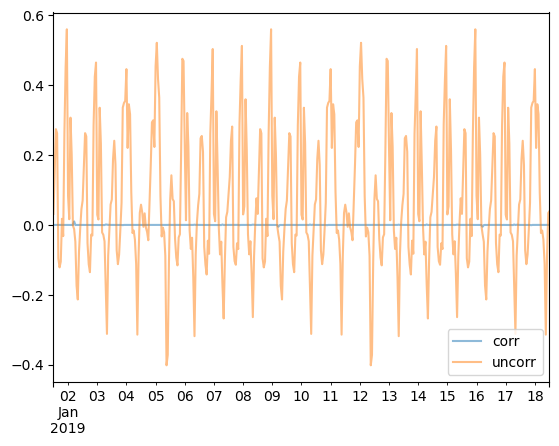

In [ ]:
# compare VF vs. corrected VF (correction is too perfect in synthetic data case, needs real data for verification)
r2.sum(axis=1).resample(rule="1 h").mean().plot(alpha=0.5, legend=True, label="corr")
r.sum(axis=1).resample(rule="1 h").mean().plot(alpha=0.5, legend=True, label="uncorr")

# Calculate period that contains leak

In [ ]:
indexer2 = pd.IndexSlice["2019-01-24 13:00:00":"2019-03-04 11:00:00"]

head_data = heads[LTownSpecifics.pressure_sensors].loc[indexer2]
inflow_data = inflows[LTownSpecifics.inflow_pipes].loc[indexer2]
pump_data = pump_flows[LTownSpecifics.pumps].loc[indexer2]

r3 = dm.run_simulation(
    heads=head_data,
    inflows=inflow_data,
    pump_flows=pump_data,
    aggregate=False
)

Applied setTimeSimulationDuration((3362400.0,)) option.
Loaded epyt instance of: dual_model.inp


c:\Users\jkoslo\.conda\envs\iole\Lib\site-packages\epyt\epanet.py:14337: UserWarning: WARNING: Valves cannot deliver enough flow.
  warnings.warn(errmssg.value.decode())


run_simulation executed in 8.67 seconds


<Axes: >

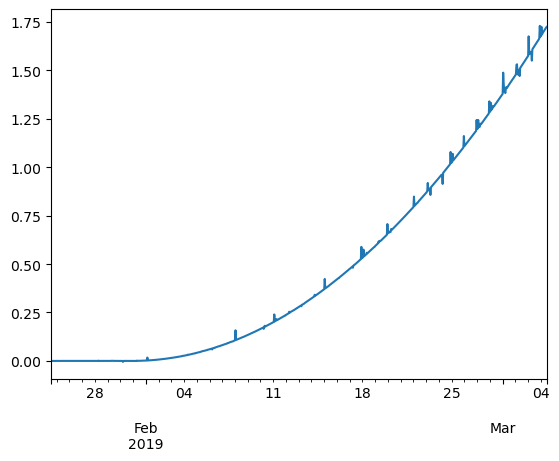

In [ ]:
r3.sum(axis=1).resample(rule="1 h").mean().plot()

# Localisation

### What's the logic here?

- VF was calculated from head (inflow, pump) data with datetime index
- VF has dt index now and can be appended to VF database
- CUSUM will determine if localisation should be performed
    - !!! missing logic: which timespan, what if the localisation is not correct? !!!
- select reconstruction period from VF database (let's say, last 7 days)
    - the same period has to be selected for heads (inflows, pump flows)

- provide data to DualModel.run_localisation
- cyclic patterns will be adjusted to fit the start time
- resampling of patterns will be performed internally to fit the provided temporal resolution
- temporary copies of the localisation slice are created and initialised in localisation worker processes
    - N_CPUs - 1 processes (or len(pipes_to_test))
    - Pool iterates over pipes_to_test (or all pipes if not provided)
    - Workers create localisation data with specified aggregation
        - WARNING! No aggregation will lead to a lot of data which is returned in memory!

In [ ]:
test_pipes = dm.nw.get_sample_pipes(pctg=0.03, min_pipes=10)[:15] # test pipes for short run
vf = r3.sum(axis=1) # virtual flow aggregate
leak_flow = vf.loc[vf.last_valid_index() - pd.Timedelta(days=7): ] # selected period

# data slices
loc_heads = heads[LTownSpecifics.pressure_sensors].loc[leak_flow.index]
loc_inflows = inflows[LTownSpecifics.inflow_pipes].loc[leak_flow.index]
loc_pump_flows = pump_flows[LTownSpecifics.pumps].loc[leak_flow.index]

In [ ]:
# also accessible via dm.last_localisation
localisation = dm.run_localisation(
    leak_flow=leak_flow,
    heads=loc_heads,
    inflows=loc_inflows,
    pump_flows=loc_pump_flows,
    pipe_list=test_pipes,
    temporal_resolution="1 h",
    aggregation="none",
)

EPANET version 20200 loaded (EPyT version v1.2.0 - Last Update: 01/08/2024).
Input File dm.inp loaded successfully.

Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\0.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\1.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\2.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\3.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\4.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\5.inp
Created localisation copy: C:\Users\jkoslo\AppData\Local\Temp\tmpzlgrzv70\6.inp
